In [1]:
import sys
# append the path of the parent directory
sys.path.append("..")

In [162]:
import math
import os
import time


import numpy as np
np.set_printoptions(legacy='1.25')

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches

import seaborn as sns
import time
import json
import pandas as pd
from ctypes import c_int32
from itertools import product
import copy


from tqdm import tqdm

from scipy.stats import pearsonr
from importlib import reload

import orjson
import gzip

from scipy.stats import entropy
from pympler import asizeof

from lib import sketches, visualization_utils, encoders, ploting, pacha_sketch, experiment_utils
reload(ploting)
reload(sketches)
reload(visualization_utils)
reload(encoders)

reload(pacha_sketch)
reload(experiment_utils)

from lib.experiment_utils import add_true_results, compute_true_counts, get_true_counts, add_true_counts_and_error, \
      compute_true_avgs, compute_true_sums

from lib.sketches import BloomFilter, CountMinSketch, H3HashFunctions, HashFunctionFamily,\
      CountMinSketchHadamard, CountMinSketchLocalHashing, deterministic_hash, simple_deterministic_hash, \
      fast_hash_xx
from lib.visualization_utils import plot_boxplot, plot_relative_error, plot_estimate_distribution, \
      plot_lineplot_p_vs_o 

from lib.encoders import minimal_b_adic_cover, minimal_spatial_b_adic_cover, BAdicCube, BAdicRange, \
      minimal_b_adic_cover_array, downgrade_b_adic_range_indices
from lib.pacha_sketch import PachaSketch, ADTree, BFParameters, CMParameters, \
      cartesian_product, get_n_updates, MaterializedCombinations, get_n_updates_customized

from lib.ploting import set_style, plot_ylabel, plot_legend

from lib import baselines
reload(baselines)

from lib.baselines import CentralDPServer, LDPServer, LDPEncoderGRR, filter_df, query_df, \
      infer_domains_and_ranges, translate_query_region, evaluate_queries, check_accruracy, \
      evaluate_queries_baselines, evaluate_equivalent_pacha_sketches, compute_relative_entropy, \
      compute_relative_entropy2

# set_style()

# Datasets

In [12]:
def add_true_results_for_dataset(dataset_name, results_folder):
    if dataset_name == "tpch":
        len_df = 599_934
        n_cat = 5
        n_num = 5
    elif dataset_name == "retail":
        len_df = 541_909
        n_cat = 3
        n_num = 3
    elif dataset_name == "census":
        len_df = 377_575
        n_cat = 7
        n_num = 3
    elif dataset_name == "bank":
        len_df = 45_211
        n_cat = 6
        n_num = 4


    path_to_estimates = f"{results_folder}{dataset_name}/{dataset_name}_random.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/{dataset_name}_random.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

    selectivities = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
    for sel in selectivities:
        path_to_estimates = f"{results_folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        path_to_true_counts = f"../results/python/{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            add_true_results(path_to_estimates, path_to_true_counts, len_df)
        except Exception as e:
            print(f"Error with path_to_estimates: {path_to_estimates}")
            print(f"Exception: {e}")
            raise

    n_cats = np.arange(1, n_cat+1)
    for n in n_cats:
        path_to_estimates = f"{results_folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        path_to_true_counts = f"../results/python/{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        add_true_results(path_to_estimates, path_to_true_counts, len_df)

    n_nums = np.arange(1, n_num+1)
    for n in n_nums:
        path_to_estimates = f"{results_folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        path_to_true_counts = f"../results/python/{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        add_true_results(path_to_estimates, path_to_true_counts, len_df)

    n_diminant = max(n_cat, n_num)
    n_mix = np.arange(1, n_diminant+1)
    for n in n_mix:
        path_to_estimates = f"{results_folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        path_to_true_counts = f"../results/python/{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        # add_true_results(path_to_estimates, path_to_true_counts, len_df)
        try:
            add_true_results(path_to_estimates, path_to_true_counts, len_df)
        except Exception as e:
            print(f"Error with path_to_estimates: {path_to_estimates}")
            print(f"Exception: {e}")
            raise

In [14]:
dataset_names = ["tpch", "retail", "census", "bank"]
results_folder = "../results/experiments_results/pacha/"

for dataset_name in dataset_names:
    add_true_results_for_dataset(dataset_name, results_folder)

results_folder = "../results/experiments_results/omni/"

for dataset_name in dataset_names:
    add_true_results_for_dataset(dataset_name, results_folder)

# Scalability

In [5]:
data_base_dir = "../../pacha_experiments/pacha_data/"

data_files = [
    "lineitem_0.1.csv",
    "lineitem_0.5.csv",
    "lineitem_0.5.csv",
    "lineitem_2.csv",
    "lineitem_8.csv",
]

limits = [187_500, 750_000, 3_000_000, 12_000_000, 48_000_000]

results_base_dir = "../results/experiments_results/scalability/"

results_files = [
    "tpchrandom_scale_187_k.csv",
    "tpchrandom_scale_750_k.csv",
    "tpchrandom_scale_3_M.csv",
    "tpchrandom_scale_12_M.csv",
    "tpchrandom_scale_48_M.csv"
]

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

for i, results_file in enumerate(results_files):
    compute_true_counts(
        path_to_estimates = f"{results_base_dir}{results_file}",
        path_to_data = f"{data_base_dir}{data_files[i]}",
        path_to_queries = path_to_queries,
        limit = limits[i]
    )

True Count:  62%|██████▏   | 124/200 [04:59<03:47,  3.00s/it]

# Guarantees

In [6]:
data_file = "lineitem_0.1.csv"

results_base_dir = "../results/experiments_results/guarantees/"

results_files = [
    "tpchrandom_eps_0.000025_p_0.0025.csv",
    "tpchrandom_eps_0.00005_p_0.005.csv",
    "tpchrandom_eps_0.0001_p_0.01.csv",
    "tpchrandom_eps_0.0002_p_0.02.csv",
    "tpchrandom_eps_0.0004_p_0.04.csv"
]

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

for i, results_file in enumerate(results_files):
    compute_true_counts(
        path_to_estimates = f"{results_base_dir}{results_file}",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

True Count: 100%|██████████| 200/200 [00:05<00:00, 36.64it/s]


# Parameters

In [7]:
data_file = "lineitem_0.1.csv"

results_base_dir = "../results/experiments_results/parameters/"

results_files = [
    "bases/tpchrandom_bases_2_2_2_2_2.csv",
    "bases/tpchrandom_bases_5_5_5_5_5.csv",
    "bases/tpchrandom_bases_5_5_5_10_2.csv",
    "bases/tpchrandom_bases_10_10_10_10_10.csv",

    "levels/tpchrandom_levels_3.csv",
    "levels/tpchrandom_levels_5.csv",
    "levels/tpchrandom_levels_7.csv",
    "levels/tpchrandom_levels_9.csv"
]

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

for i, results_file in enumerate(results_files):
    compute_true_counts(
        path_to_estimates = f"{results_base_dir}{results_file}",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

True Count: 100%|██████████| 200/200 [00:05<00:00, 36.82it/s]


# Memory Budget (Streaming)

In [23]:
path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

get_true_counts(chunks[0], path_to_queries)

True Count: 100%|██████████| 200/200 [00:01<00:00, 164.77it/s]


array([12915,  6205, 15279,   837,  3625,  2641,  6109,  2172, 21718,
       24546, 24571,   714,  6467, 24417, 20297,  2519, 14664, 10088,
        1912,  3524,  2664, 19414, 15350,  1818, 12509,  5957,  7284,
        6011,  3376,  5440, 24607, 24461,  2960, 10636,  6704,  4583,
        2246, 26144, 15262, 13848,  6470,  2022,  6420,  6411,  3651,
        5989, 24436, 20689, 15304,  4132,  2714, 14585,  6506,  6050,
       24447, 18086,  5938,  3533, 12528,   302,  6133,  2262,  3769,
        5984,  3349, 24987,  2226,  3878, 14269,  6650,  6475, 24567,
         844,   498, 24681,  2066, 21671, 24626, 14331, 24867, 12161,
        5201,  7205, 50325,  2401, 24631,  1452,  2317, 13103,  6523,
        2081,  5622,  7923,   338,   703, 24428,   239, 13504,  3545,
       14793,  2278,  3470,  3523,  4074, 15518,  7122, 12089, 17986,
       24663,  2873, 15281,   923,   915, 16261,  6513,   914, 26144,
       24925, 24777,  7205,  3441, 14331,   330,  7285,  3394, 22234,
        6004,  2915,

In [ ]:
data_file = "../../pacha_experiments/pacha_data/lineitem_8.csv"

data_df = pd.read_csv(data_file).head(3_000_000)

In [5]:
n_splits = 100
chunk_size = 100_000
dfs = []
for i in range(n_splits):
    start = i * chunk_size
    # Make the last chunk include any remainder rows
    end = (i + 1) * chunk_size if i < n_splits - 1 else len(data_df)
    dfs.append(data_df.iloc[start:end].copy().reset_index(drop=True))

In [ ]:
# from dateutil.parser import ParserError
# data_file = "../../pacha_experiments/pacha_data/lineitem_8.csv"

# data_df = pd.read_parquet(data_file).head(10_000_000)

# chunks = np.array_split(data_df, 100)

mem_budgets = [64, 128, 256, 512, 1024]  # in MB

limits = [30]*5

results_base_dir = "../results/experiments_results/memory_budget/"

approaches = ["pacha", "omni"]

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

prev_true_counts = np.zeros(200, dtype=np.int32)
# prev_true_counts = get_true_counts(data_df.head(84*100_000), path_to_queries)

len_df = 0

for j, chunk in enumerate(dfs):
    print(f"Processing chunk {j + 1}/{len(dfs)}...")
    # if j == 0:
    #     temp_df = chunk
    # else:
    #     temp_df = pd.concat([temp_df, chunk], ignore_index=True)
    # if j+1 < 85:
    #     continue

    len_df += len(chunk)
    true_counts = get_true_counts(chunk, path_to_queries) 
    true_counts = true_counts + prev_true_counts
    prev_true_counts = np.copy(true_counts)

    for i in range(len(mem_budgets)):
        if j + 1 > limits[i]:
            continue
        for approach in approaches:
            results_file = f"tpchmemory_{mem_budgets[i]}_MB_{j+1}.csv"
            path_to_estimates = f"{results_base_dir}{approach}/{results_file}"
            if not os.path.isfile(path_to_estimates):
                # if file doesn't exist, skip
                continue
            else:
                # file exists -> call and catch parser errors so we can print the path
                try:
                    add_true_counts_and_error(path_to_estimates, len_df, np.copy(true_counts))
                except Exception as e:
                    # pandas ParserError lives in pandas.errors; also check message for C tokenizer errors
                    msg = str(e)
                    # if isinstance(e, ParserError) or "Error tokenizing" in msg or "Expected" in msg:
                    print(f"ParserError while parsing: {path_to_estimates}")
                    # re-raise other exceptions
                    raise
                # we've handled the file here, skip the unguarded call below
                continue
            # add_true_counts_and_error(path_to_estimates, true_counts, len(temp_df))

In [9]:
for j in range(1,30):
    for i in range(len(mem_budgets)):
        if j + 1 > limits[i]:
            continue
        for approach in approaches:
            results_file = f"tpchmemory_{mem_budgets[i]}_MB_{j+1}.csv"
            path_to_estimates = f"{results_base_dir}{approach}/{results_file}"
            if not os.path.isfile(path_to_estimates):
                continue

            old = "0,0,0,0,0,0,0,0,0,0,0,0"
            new = "0,0,0,0,0,0,0,0,0,0,0"

            with open(path_to_estimates, "r", encoding="utf-8", errors="replace") as f:
                content = f.read()

            if old in content:
                content = content.replace(old, new)
                with open(path_to_estimates, "w", encoding="utf-8") as f:
                    f.write(content)
                print(f"Patched: {path_to_estimates}")

Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_2.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_2.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_3.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_3.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_4.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_4.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_5.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_5.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_6.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_6.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_64_MB_7.csv
Patched: ../results/experiments_results/memory_budget/pacha/tpchmemory_128_MB_7.cs

# Aggregates

In [205]:
data_base_dir = "../../pacha_experiments/pacha_data/"
data_file = "lineitem_0.1.csv"

results_base_dir = "../results/experiments_results/aggregates/"

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

compute_true_sums(
        path_to_estimates = f"{results_base_dir}tpch_sums.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
        agg_col="q6"
    )

compute_true_avgs(
        path_to_estimates = f"{results_base_dir}tpch_avgs.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

True Average: 100%|██████████| 200/200 [00:06<00:00, 28.72it/s]


,estimates,runtime,forced,relevant_nodes,cat_regions,b_adic_cubes,num_regions,candidate_regions,query_regions,level_0_queries,level_1_queries,level_2_queries,level_3_queries,level_4_queries,true_avgs,absolute_error,normalized_error,relative_error
0,1840.215832,9.429599,-1,1,1,8257,289,289,289,240,28,18,3,0,36918,35077.784168,0.058469,0.950154
1,1853.761774,0.554201,-1,7,7,17,17,119,70,21,21,7,21,0,37052,35198.238226,0.058670,0.949969
2,1841.658875,7.824700,-1,1,1,8257,233,233,233,209,7,12,5,0,36950,35108.341125,0.058520,0.950158
3,1684.648977,50.130500,-1,1,1,108065,2749,2749,874,53,196,561,64,0,35944,34259.351023,0.057105,0.953131
4,1815.537369,0.592301,-1,1,1,17,17,17,17,6,4,3,4,0,36682,34866.462631,0.058117,0.950506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1848.506741,0.092300,-1,1,1,17,17,17,17,1,5,8,3,0,36961,35112.493259,0.058527,0.949988
196,2080.400972,51.917900,3,1,1,360,162,162,162,0,0,0,162,0,42192,40111.599028,0.066860,0.950692
197,1841.227216,0.110300,-1,1,1,17,17,17,17,6,4,3,4,0,36938,35096.772784,0.058501,0.950154
198,2044.934030,56.270499,3,1,1,360,198,198,198,0,0,0,198,0,41151,39106.065970,0.065184,0.950307


In [154]:
compute_true_counts(
        path_to_estimates = f"{results_base_dir}tpch_sample_count.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

compute_true_sums(
        path_to_estimates = f"{results_base_dir}tpch_sample_sum.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
        agg_col="q6"
    )

True Sum: 100%|██████████| 200/200 [00:05<00:00, 35.67it/s]


,estimates,runtime,true_sums,absolute_error,normalized_error,relative_error
0,1.454594e+08,4.9206,147932195,2.472791e+06,4.121772,0.016716
1,7.041908e+07,2.8615,71699120,1.280044e+06,2.133642,0.017853
2,1.729669e+08,2.2766,175466671,2.499816e+06,4.166818,0.014247
3,1.012274e+07,1.3707,9756231,3.665112e+05,0.610919,0.037567
4,3.836373e+07,0.9339,39474990,1.111264e+06,1.852311,0.028151
...,...,...,...,...,...,...
195,3.763019e+07,1.0158,39589809,1.959615e+06,3.266385,0.049498
196,5.648197e+07,2.6167,60414594,3.932627e+06,6.555099,0.065094
197,4.129785e+07,1.0560,39426720,1.871134e+06,3.118900,0.047459
198,7.210620e+07,2.5689,74043831,1.937631e+06,3.229741,0.026169


In [155]:
df_sums = pd.read_csv(f"{results_base_dir}tpch_sums.csv")
df_avgs = pd.read_csv(f"{results_base_dir}tpch_avgs.csv")

df_sample_counts = pd.read_csv(f"{results_base_dir}tpch_sample_count.csv")
df_sample_sums = pd.read_csv(f"{results_base_dir}tpch_sample_sum.csv")

In [156]:
print(compute_relative_entropy(df_sample_sums, col='true_sums'))
print(compute_relative_entropy2(df_sample_sums, col='true_sums'))

df_sample_sums[["absolute_error","relative_error", "normalized_error", "runtime"]].describe()

0.00020997001875025663
0.00020997000985711715


,absolute_error,relative_error,normalized_error,runtime
count,2.000000e+02,200.000000,200.000000,200.000000
mean,2.620090e+06,0.032784,4.367297,1.796832
std,2.013049e+06,0.026876,3.355451,0.925040
min,0.000000e+00,0.000000,0.000000,0.564500
25%,9.783549e+05,0.017025,1.630771,0.989250
50%,2.120786e+06,0.027202,3.535032,1.703400
75%,4.216919e+06,0.037892,7.028972,2.438375
max,7.952684e+06,0.173968,13.255932,4.920600


In [146]:
print(compute_relative_entropy(df_sample_sums, col='true_sums'))
print(compute_relative_entropy2(df_sample_sums, col='true_sums'))

df_sample_sums[["absolute_error","relative_error", "normalized_error", "runtime"]].describe()

0.00017305883842384125
0.00017305883800045705


,absolute_error,relative_error,normalized_error,runtime
count,2.000000e+02,200.000000,200.000000,200.000000
mean,2.818964e+07,0.024559,46.987898,1.763618
std,2.327284e+07,0.028573,38.792340,0.869435
min,0.000000e+00,0.000000,0.000000,0.514800
25%,9.634962e+06,0.006896,16.060036,0.991400
50%,2.107364e+07,0.015883,35.126589,1.715350
75%,4.464500e+07,0.030836,74.416512,2.293550
max,9.440025e+07,0.187639,157.351059,5.148200


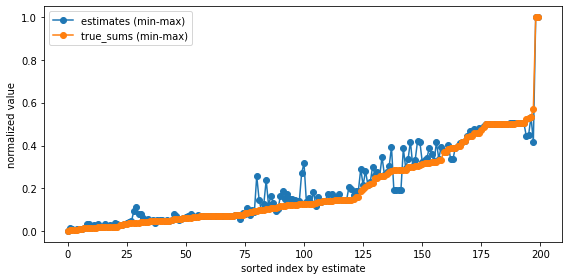

In [141]:
plot_estimate_distribution(df_sums)

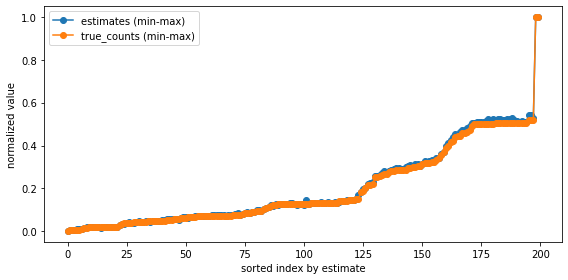

In [157]:
plot_estimate_distribution(df_sample_counts, col='true_counts')

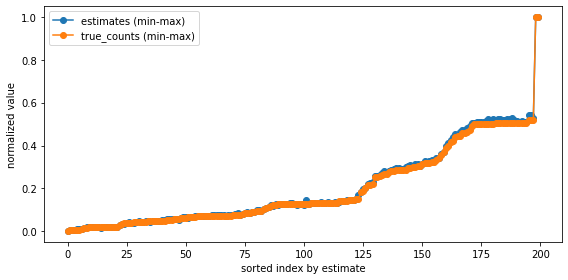

In [148]:
plot_estimate_distribution(df_sample_counts, col='true_counts')

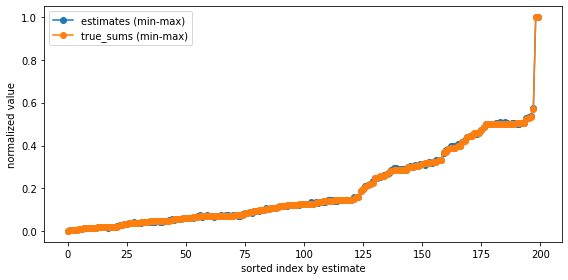

In [145]:
plot_estimate_distribution(df_sample_sums)

In [147]:
print(compute_relative_entropy(df_sums, col='true_sums'))
print(compute_relative_entropy2(df_sums, col='true_sums'))

df_sums[["absolute_error","relative_error", "normalized_error", "runtime"]].describe()

0.017918315914929074
0.017918315893506336


,absolute_error,relative_error,normalized_error,runtime
count,2.000000e+02,200.000000,200.000000,200.000000
mean,2.507075e+08,0.204731,417.891746,10.819131
std,3.908347e+08,0.338314,651.462902,18.285471
min,0.000000e+00,0.000000,0.000000,0.008200
25%,3.844651e+06,0.004452,6.408457,0.179350
50%,8.653133e+07,0.079213,144.234742,2.786750
75%,2.910487e+08,0.253604,485.134610,10.864975
max,2.129931e+09,1.928839,3550.276242,96.163300


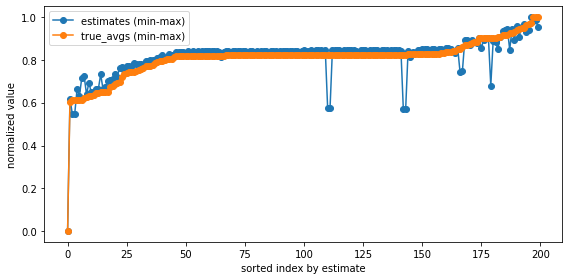

In [144]:
plot_estimate_distribution(df_avgs, col='true_avgs')

In [133]:
print(compute_relative_entropy(df_avgs, col='true_avgs'))
print(compute_relative_entropy2(df_avgs, col='true_avgs'))

df_avgs[["absolute_error","relative_error", "normalized_error"]].describe()

0.0020231167561710825
0.0020229935025094753


,absolute_error,relative_error,normalized_error
count,200.000000,200.000000,200.000000
mean,836.062953,0.022935,0.001394
std,2029.348786,0.055006,0.003383
min,0.000000,0.000000,0.000000
25%,10.209238,0.000284,0.000017
50%,105.958499,0.002960,0.000177
75%,664.081637,0.019119,0.001107
max,12069.378320,0.325478,0.020118


# Sampling

In [160]:
results_folder = "../results/experiments_results/sample/"
sel = 0.08
f"{results_folder}selectivities/tpch_sample_count_sel_{sel}.csv"

'../results/experiments_results/sample/selectivities/tpch_sample_count_sel_0.08.csv'

In [196]:
data_base_dir = "../../pacha_experiments/pacha_data/"
data_file = "lineitem_0.1.csv"

results_folder = "../results/experiments_results/"

selectivities = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
for sel in selectivities:
    path_to_queries = f"../../PachaSketch/src/main/resources/queries/tpch/selectivities/tpch_sel_{sel}.json"
    
    path_to_estimates = f"{results_folder}sample/selectivities/tpch_sample_count_sel_{sel}.csv"
    compute_true_counts(
        path_to_estimates = path_to_estimates,
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

    path_to_estimates = f"{results_folder}sample/selectivities/tpch_sample_sum_sel_{sel}.csv"
    compute_true_sums(
        path_to_estimates = path_to_estimates,
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
        agg_col="q6"
    )

    path_to_estimates = f"{results_folder}pacha/tpch/selectivities/tpch_sum_sel_{sel}.csv"
    compute_true_sums(
        path_to_estimates = path_to_estimates,
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
        agg_col="q6"
    )

True Sum: 100%|██████████| 200/200 [00:05<00:00, 37.02it/s]


(<Figure size 576x432 with 1 Axes>,
 <Axes: xlabel='selectivity', ylabel='normalized error'>)

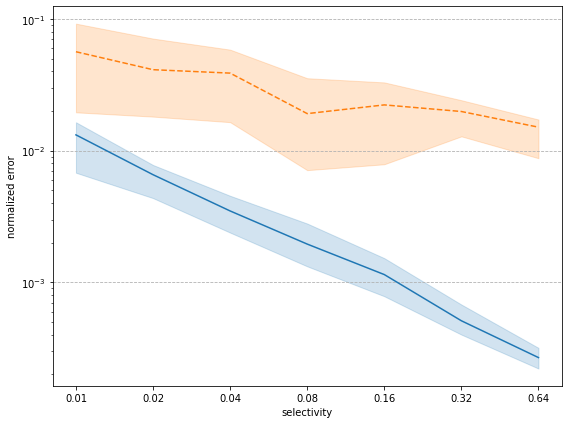

In [183]:
base_results_path = '../results/experiments_results/'
dataset_name = 'tpch'
results = []

for sel in selectivities:
    result_df = pd.read_csv(f"{base_results_path}pacha/{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv")
    result_df['approach'] = 'P-'+str(sel)
    results.append(result_df)

    result_df = pd.read_csv(f"{results_folder}selectivities/tpch_sample_count_sel_{sel}.csv")
    result_df['approach'] = 'S-'+str(sel)
    results.append(result_df)

combined_df = pd.concat(results, ignore_index=True)
labels = combined_df['approach'].unique()

custom_palette = {"pacha" : "tab:blue", "omni" : "tab:orange"}

plot_lineplot_p_vs_o(results, x_label='selectivity', col_y='relative_error', log_scale=True, palette=custom_palette)

(<Figure size 576x432 with 1 Axes>,
 <Axes: xlabel='selectivity', ylabel='normalized error'>)

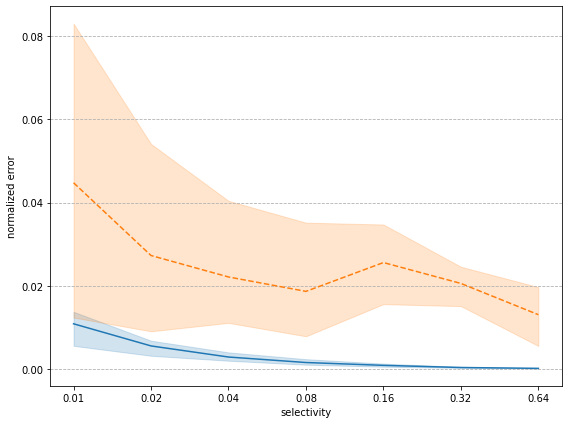

In [201]:
base_results_path = '../results/experiments_results/'
dataset_name = 'tpch'
results = []

for sel in selectivities:
    result_df = pd.read_csv(f"{base_results_path}pacha/{dataset_name}/selectivities/{dataset_name}_sum_sel_{sel}.csv")
    result_df['approach'] = 'P-'+str(sel)
    results.append(result_df)

    result_df = pd.read_csv(f"{base_results_path}sample/selectivities/tpch_sample_sum_sel_{sel}.csv")
    result_df['approach'] = 'S-'+str(sel)
    results.append(result_df)

combined_df = pd.concat(results, ignore_index=True)
labels = combined_df['approach'].unique()

custom_palette = {"pacha" : "tab:blue", "omni" : "tab:orange"}

plot_lineplot_p_vs_o(results, x_label='selectivity', col_y='relative_error', log_scale=False, palette=custom_palette)

In [198]:
filt = combined_df[combined_df["approach"].str.startswith("S")]
filt["runtime"].describe()

count    1400.000000
mean        2.029062
std         1.358158
min         0.399800
25%         1.298125
50%         1.650500
75%         2.372900
max        11.620500
Name: runtime, dtype: float64

In [186]:
filt = combined_df[combined_df["approach"].str.startswith("P")]
filt["runtime"].describe()

count    1400.000000
mean        0.348114
std         1.442884
min         0.007986
25%         0.065928
50%         0.083639
75%         0.124116
max        14.774273
Name: runtime, dtype: float64

In [189]:
filt[['candidate_regions', 'query_regions']].describe()

,candidate_regions,query_regions
count,1400.000000,1400.000000
mean,122.943571,72.475714
std,565.551791,339.900035
min,0.000000,0.000000
25%,10.000000,10.000000
50%,15.000000,14.000000
75%,22.000000,20.000000
max,6447.000000,3686.000000


In [174]:
sel = 0.64    
result_df = pd.read_csv(f"{results_folder}selectivities/tpch_sample_count_sel_{sel}.csv")

col = 'true_counts'
print(compute_relative_entropy(result_df, col=col))
print(compute_relative_entropy2(result_df, col=col))

result_df[["absolute_error","relative_error", "normalized_error", "runtime"]].describe()

1.6324063423484958e-05
0.35353510691912915


,absolute_error,relative_error,normalized_error,runtime
count,200.000000,200.000000,200.000000,200.000000
mean,4866.807100,0.012668,0.008112,3.224477
std,2223.338489,0.005786,0.003706,1.487392
min,36.301573,0.000095,0.000061,1.422800
25%,3366.322223,0.008763,0.005611,1.768250
50%,5796.479509,0.015086,0.009662,3.176650
75%,6626.443098,0.017246,0.011045,4.279000
max,7862.137920,0.020454,0.013105,8.728000


In [175]:
data_base_dir = "../../pacha_experiments/pacha_data/"
data_file = "lineitem_8.csv"

results_base_dir = "../results/experiments_results/sample/tpch/"

path_to_queries = "../../PachaSketch/src/main/resources/queries/tpch/tpch_random.json"

compute_true_counts(
        path_to_estimates = f"{results_base_dir}tpch_sample_count.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
    )

compute_true_sums(
        path_to_estimates = f"{results_base_dir}tpch_sample_sum.csv",
        path_to_data = f"{data_base_dir}{data_file}",
        path_to_queries = path_to_queries,
        agg_col="q6"
    )

True Sum: 100%|██████████| 200/200 [08:48<00:00,  2.64s/it]


,estimates,runtime,true_sums,absolute_error,normalized_error,relative_error
0,1.173330e+10,8.0257,12153281779,4.199834e+08,8.751658,0.034557
1,5.835934e+09,4.4566,5836709362,7.755942e+05,0.016162,0.000133
2,1.394481e+10,4.6266,14407190178,4.623800e+08,9.635124,0.032094
3,7.248844e+08,3.6570,749541066,2.465666e+07,0.513798,0.032896
4,3.292695e+09,2.5862,3273272100,1.942316e+07,0.404742,0.005934
...,...,...,...,...,...,...
195,3.188263e+09,2.6838,3272616978,8.435421e+07,1.757782,0.025776
196,4.674890e+09,7.4191,4674773016,1.170864e+05,0.002440,0.000025
197,3.053115e+09,3.8082,3271722339,2.186075e+08,4.555367,0.066817
198,5.854363e+09,8.5337,5638549203,2.158138e+08,4.497151,0.038275


In [203]:
results_files = [
    f'{base_results_path}pacha/tpch/tpch_random.csv',
    f"{base_results_path}sample/tpch/tpch_sample_count.csv"
]

labels = ['pacha', 'sample']

results = []
relative_entropies = []
box_data = []

for i, file in enumerate(results_files):
    result_df = pd.read_csv(file)
    result_df['approach'] = labels[i]
    box_data.append(result_df['relative_error'].values)
    results.append(result_df)
    re = compute_relative_entropy(result_df, col='true_counts')
    relative_entropies.append(re)
    print(f'Relative Entropy for {labels[i]}: {re}')

palette = {
    'pacha': 'tab:blue',
    'sample': 'tab:orange'
}
combined_df = pd.concat(results, ignore_index=True)
bar_values = relative_entropies

Relative Entropy for pacha: 0.014172697707073882
Relative Entropy for sample: 0.00023054936509546211


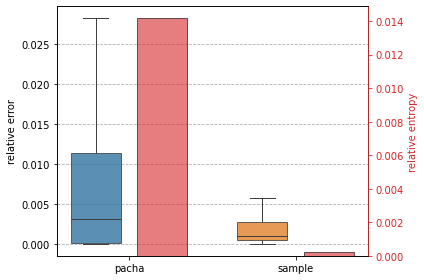

In [204]:
# fig, ax1 = plt.subplots(figsize=(w*0.4, 1.4))
fig, ax1 = plt.subplots()

# --- Boxplots ---
sns.boxplot(
    data=combined_df,
    x='approach',
    y='normalized_error',
    hue='approach',
    palette=palette,
    ax=ax1,
    showfliers=False,
    width=0.3
)

for patch in ax1.patches:
    patch.set_facecolor(patch.get_facecolor())
    patch.set_linewidth(1.0)
    patch.set_alpha(0.8)

ax1.set_ylabel("relative error")

# --- Secondary axis ---
ax2 = ax1.twinx()

# Get categorical positions from seaborn
x_positions = np.arange(len(labels))

ax2.bar(
    x_positions + 0.4,   # shift bars to the right
    bar_values,
    width=0.3,
    color='tab:red',
    edgecolor='black',
    linewidth=1.0,
    alpha=0.6
)
ax1.set_xlabel('')

rel_entropy_color = 'tab:red'
ax2.set_ylabel("relative entropy", color=rel_entropy_color)
ax2.tick_params(axis='y', labelcolor=rel_entropy_color)
ax2.spines['right'].set_color(rel_entropy_color)
ax2.tick_params(axis='y', colors=rel_entropy_color)

ax1.grid(True, axis='y', linestyle='--')

# Align ticks between box + bar
ax1.set_xticks(x_positions + 0.20)
ax1.set_xticklabels(labels)

# fig.savefig('../figures/aggregates/aggregates.pdf', bbox_inches='tight', pad_inches=0.05)

plt.tight_layout()
plt.show()
